**Caso de estudio:**
Una entidad del sector salud desea implementar un sistema de analítica de datos para apoyar la identificación temprana de pacientes con diabetes. El objetivo es utilizar información clínica de los pacientes para desarrollar modelos que permitan clasificar si una persona presenta o no diabetes, facilitando la toma de decisiones médicas y estrategias de prevención.

Para este análisis se utilizará la base de datos Pima Indians Diabetes Database, la cual contiene 768 registros de pacientes y 9 variables clínicas relacionadas con factores que pueden influir en el desarrollo de la diabetes.

En el estudio se aplicarán diferentes técnicas de analítica como Naive Bayes, Decision Tree y K-Means, con el fin de analizar patrones en los datos, clasificar pacientes según su probabilidad de padecer diabetes y comparar el desempeño de los modelos.

Para este proceso se utilizarán las siguientes variables:

Pregnancies: Indica el número de embarazos que ha tenido la paciente. Esta variable puede estar relacionada con factores metabólicos que influyen en el desarrollo de diabetes.

Glucose: Representa el nivel de glucosa en sangre. Es una de las variables más importantes para identificar la presencia de diabetes.

BloodPressure: Corresponde a la presión arterial diastólica del paciente, la cual puede relacionarse con diferentes condiciones de salud metabólica.

SkinThickness: Indica el grosor del pliegue cutáneo del tríceps, una medida utilizada para estimar la cantidad de grasa corporal.

Insulin: Representa el nivel de insulina en sangre del paciente, variable clave para analizar el metabolismo de la glucosa.

BMI (Body Mass Index): Corresponde al índice de masa corporal, indicador que permite evaluar si una persona tiene bajo peso, peso normal, sobrepeso u obesidad.

DiabetesPedigreeFunction: Mide la probabilidad de desarrollar diabetes con base en antecedentes familiares y factores genéticos.

Age: Representa la edad del paciente en años.

Outcome: Variable objetivo que indica si el paciente tiene diabetes (1) o no tiene diabetes (0).

El análisis se realizará utilizando estos registros para entrenar los modelos y evaluar su capacidad para clasificar correctamente la presencia de diabetes en los pacientes, permitiendo identificar patrones de riesgo y apoyar la toma de decisiones clínicas.

**Modelo Clustering K-Means**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns  #herramienta para graficas estadisticas
from sklearn.cluster import KMeans #herramienta de clustering

In [ ]:
nxl="/content/diabetes.csv"
XDB = pd.read_csv(nxl)

# Mostrar las primeras filas de la base
display(XDB.head(10))

# Mostrar número de observaciones y variables
print("Número de observaciones:", XDB.shape[0])
print("Número de variables:", XDB.shape[1])

# Mostrar tipo de dato de cada variable
print("\nTipos de datos:")
print(XDB.dtypes)

# Contar cuántos pacientes tienen y no tienen diabetes
print("\nConteo de la variable Outcome:")
print(XDB["Outcome"].value_counts())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Número de observaciones: 768
Número de variables: 9

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Conteo de la variable Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


**Analisis de correlacion**


Correlación de las variables con Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


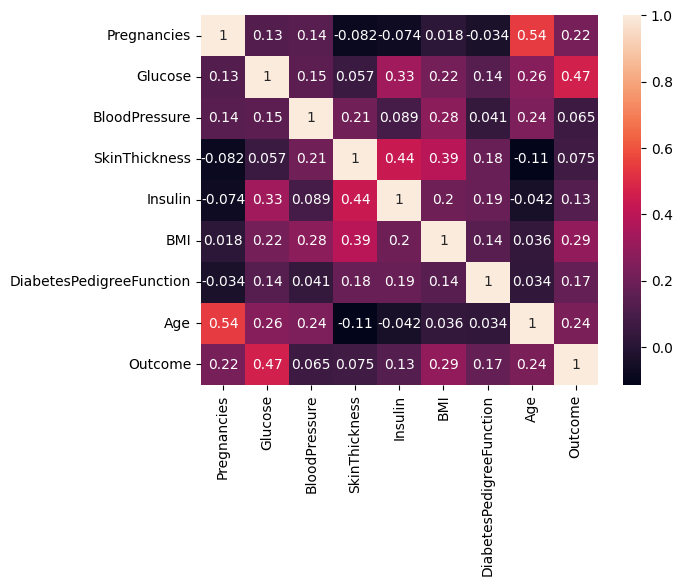

In [ ]:
XDB2 = XDB.iloc[:,[0,1,2,3,4,5,6,7,8]]
sns.heatmap(XDB2.corr(), annot=True)

print("\nCorrelación de las variables con Outcome:")
print(XDB2.corr()["Outcome"].sort_values(ascending=False))

,Pregnancies,Glucose,BMI,Age
0,3.698113,121.740566,32.527358,32.367925
1,4.273684,178.905263,35.890526,37.842105
2,3.289796,99.310204,29.988571,29.771429
3,3.506329,72.075949,29.839241,29.708861
4,4.963504,146.109489,33.287591,39.642336


El numero de datos por cluster es: [211  95 246  79 137]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster,cluster
0,6,148,72,35,0,33.6,0.627,50,1,1,4
1,1,85,66,29,0,26.6,0.351,31,0,1,3
2,8,183,64,0,0,23.3,0.672,32,1,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2,2
4,0,137,40,35,168,43.1,2.288,33,1,4,4
...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4,2
764,2,122,70,27,0,36.8,0.340,27,0,1,0
765,5,121,72,23,112,26.2,0.245,30,0,2,0
766,1,126,60,0,0,30.1,0.349,47,1,1,0


,Diabetes,No Diabetes
0,75,136
1,79,16
2,37,209
3,6,73
4,71,66


,Diabetes,NoDiabetes
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


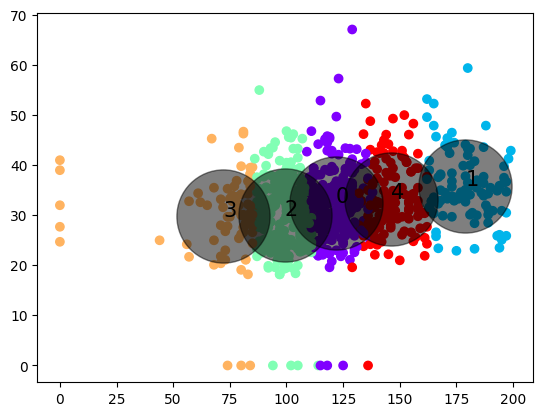

In [ ]:
np.random.seed()
NC=5
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd)
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)
ydp=mkm.labels_ #Me indica enq eu cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Numero de datos por segmento
print("El numero de datos por cluster es:",NDc)

#Porcentaje de tener diabetes
XDB2['cluster']=ydp
display(XDB2)

Napr=XDB2.groupby('cluster').agg({"Outcome": lambda x: (x==1).sum()})
Nprn=XDB2.groupby('cluster').agg({"Outcome": lambda x: (x==0).sum()})

Napr2=Napr/(Napr+Nprn); Nprn2=Nprn/(Napr+Nprn)
df2=pd.DataFrame(np.column_stack((Napr,Nprn)),columns=['Diabetes','No Diabetes'])
display(df2)

#Para que la decision sea en porcentaje
Ndiab2=Ndiab/(Ndiab+Nnodiab); Nnodiab2=Nnodiab/(Ndiab+Nnodiab)

df2=pd.DataFrame(np.column_stack((Ndiab2,Nnodiab2)),columns=['Diabetes','NoDiabetes'])
display(df2)

#Grafica de clusters
centers=mkm.cluster_centers_ #Centroides, perfil o segmento
ing=np.array(XD.iloc[:,1])
egr=np.array(XD.iloc[:,2])

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap='rainbow')
plt.scatter(centers[:,1],centers[:,2],c='black',s=4500,alpha=0.5)
plt.xlabel='BMI'
plt.ylabel='AGE'

for i,center in enumerate(centers):
  plt.text(center[1], center[2], str(i), color = 'black', fontsize = 15)
plt.show()

**Analisis de resultados**
La visualización muestra que los grupos se organizan principalmente según los niveles de glucosa, lo que indica que esta variable ejerce un gran peso en la formación de los clusters.

El cluster 1 agrupa una proporción más alta de pacientes con diabetes (79 casos frente a 16 sin diabetes), lo que sugiere que el centroide de este grupo refleja características vinculadas a un mayor riesgo de la enfermedad.

Por el contrario, el cluster 0 incluye más pacientes sin diabetes (136 frente a 75 con diabetes), lo que indica que el perfil promedio de este grupo podría asociarse a valores menos críticos en variables como glucosa o IMC.


**Modelo Naive Bayes**

In [ ]:
import numpy as np #Numerica por excelencia
import pandas as pd #Comunicación con los archivos de excel
#Librerias especificas: Ej. Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [ ]:
XD=XDB[["Glucose","BMI","Age","Pregnancies"]]
XD.head(10)
yd=XDB[["Outcome"]] #Esta la variable de decision
yd.head()

mnb=GaussianNB()
mnb.fit(XD,yd) #Ajustar Variables de entrada-salida

#Mostrar las medias de las variables
u=mnb.theta_
sigma=mnb.var_; sigma= np.sqrt(sigma)
print("Glucose","BMI","Age","Pregnancies")
print(u)
print("Las desviaciones son: ")
print(sigma)

ydp=mnb.predict(XD) #Esto el lo que el modelo aprende - ydp de pronostico
cm=confusion_matrix(yd,ydp)
print(cm)

#Matriz de confusion para la evaluacion del modelo:
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)
Ex=((VP+VN)/TDatos)*100
print("Exactitud: ", Ex)
TE=(1-Ex)
print("Tasa de error: ", TE)
Se=(VP/(VP+FN))*100
print("Sensibilidad: ", Se)
Es=(VN/(VN+FP))*100
print("Especifisidad: ", Es)
Pr=(VP/(VP+FP))*100
print("Precision: ", Pr)
PrN=(VN/(VN+FN))*100
print("Prediccion negativa: ", PrN)

Glucose BMI Age Pregnancies
[[109.98        30.3042      31.19         3.298     ]
 [141.25746269  35.14253731  37.06716418   4.86567164]]
Las desviaciones son: 
[[26.11504549  7.68216137 11.65598134  3.01416606]
 [31.87997754  7.24940434 10.94777141  3.73425273]]
[[426  74]
 [110 158]]
Exactitud:  76.04166666666666
Tasa de error:  -75.04166666666666
Sensibilidad:  58.95522388059702
Especifisidad:  85.2
Precision:  68.10344827586206
Prediccion negativa:  79.47761194029852


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**analisis de resultados:**

Según los resultados obtenidos, el modelo alcanza una exactitud cercana al 76%, lo que refleja un rendimiento adecuado al momento de clasificar pacientes con y sin diabetes. Esto significa que el modelo logra identificar correctamente una gran parte de los casos, aunque todavía existe un margen de error aproximado del 24%.

La precisión del 68.1% sugiere que una buena proporción de los pacientes que el modelo clasifica como diabéticos realmente padecen la enfermedad. Asimismo, la especificidad del 85.2% indica que el modelo es bastante efectivo al reconocer correctamente a los pacientes que no presentan diabetes.

No obstante, la sensibilidad del 58.9% muestra que todavía hay algunos casos de diabetes que el modelo no logra detectar. En términos generales, se puede concluir que el modelo tiene mejor desempeño al identificar pacientes sanos que al detectar todos los casos positivos de diabetes.

**Arboles de decision**

In [ ]:
XD=XDB.iloc[:,[0,1,5,7]]
yd=XDB.iloc[:,8]
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd)
ydp=mar.predict(XD)
#Despliegue del arbol
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
vs=["Glucose", "BMI", "Age", "Pregnancies"]
dot_data=export_graphviz(mar,feature_names=vs)
graph=graph_from_dot_data(dot_data)
graph.write_png("arbol.png")

#Matriz de confusion para la evaluacion del modelo:
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)
Ex=((VP+VN)/TDatos)*100
print("Exactitud: ", Ex)
TE=(1-Ex)
print("Tasa de error: ", TE)
Se=(VP/(VP+FN))*100
print("Sensibilidad: ", Se)
Es=(VN/(VN+FP))*100
print("Especifisidad: ", Es)
Pr=(VP/(VP+FP))*100
print("Precision: ", Pr)
PrN=(VN/(VN+FN))*100
print("Prediccion negativa: ", PrN)

Exactitud:  76.30208333333334
Tasa de error:  -75.30208333333334
Sensibilidad:  61.56716417910447
Especifisidad:  84.2
Precision:  67.62295081967213
Prediccion negativa:  80.34351145038168


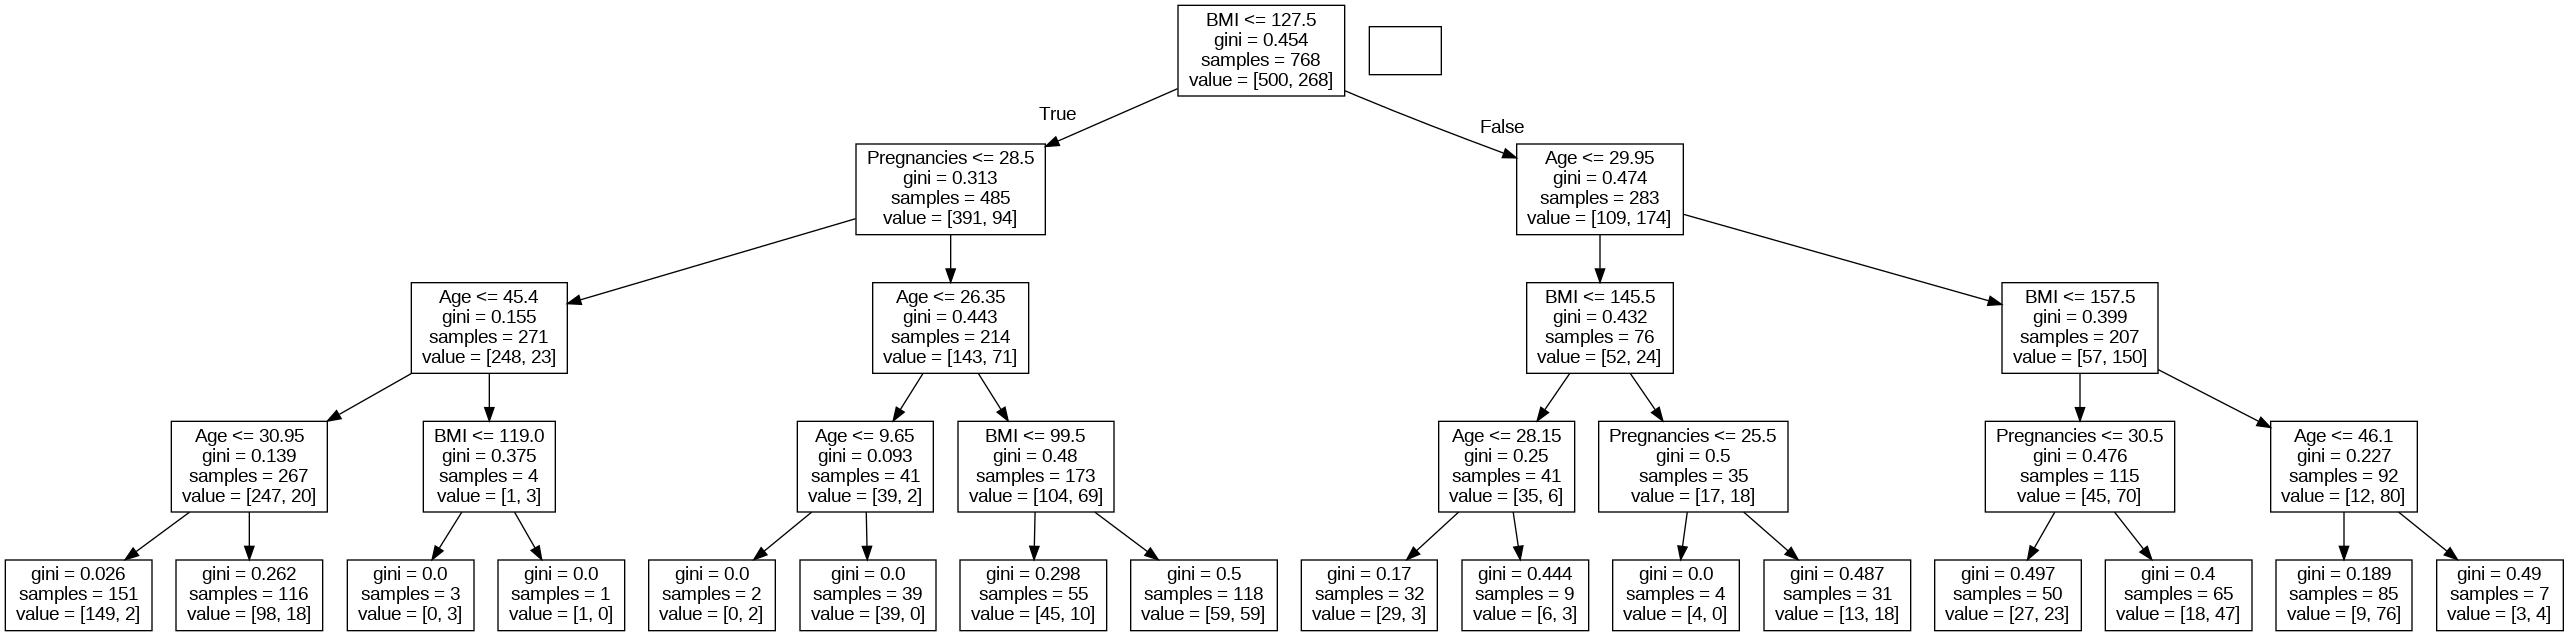

**Analisis de resultados**
El árbol de decisión generado con cuatro niveles permite reconocer cuáles variables tienen mayor influencia en la clasificación de pacientes con diabetes y sin diabetes.

La variable ubicada en la raíz del árbol es BMI, lo que sugiere que el índice de masa corporal es uno de los factores más determinantes para realizar la primera división de los datos dentro del modelo.

Dentro del árbol se observan 7 nodos puros. El nodo que concentra la mayor cantidad de registros contiene 39 observaciones, con un valor [39, 0], lo cual indica que todos los individuos en ese nodo corresponden a pacientes no diabéticos.

Además, las reglas generadas por el árbol muestran que cuando se presentan valores bajos en variables como la edad y el BMI, los registros son clasificados completamente en la categoría de pacientes sin diabetes dentro del modelo.

**Nueva persona**

In [ ]:
XDp = [2,85,65,29,94,39.6,0.93,27]

paciente_NB = pd.DataFrame([[XDp[1], XDp[5], XDp[7], XDp[0]]],
columns=["Glucose", "BMI", "Age", "Pregnancies"])

paciente_Arbol = pd.DataFrame([[XDp[0], XDp[1], XDp[5], XDp[7]]],
columns=["Pregnancies", "Glucose", "BMI", "Age"])

#Naive Bayes
pred_nb = mnb.predict(paciente_NB)
print(f"Resultado Naive Bayes: {'Diabetes' if pred_nb[0] == 1 else 'No Diabetes'}")

#Arbol de Decisión
pred_arbol = mar.predict(paciente_Arbol)
print(f"Resultado Árbol de Decisión: {'Diabetes' if pred_arbol[0] == 1 else 'No Diabetes'}")

# C. Modelo K-Means (Segmentación)
cluster_paciente = mkm.predict(paciente_Arbol)
prob_diabetes = Napr2.iloc[cluster_paciente[0], 0] * 100


print(f"Resultado K-Means: El paciente pertenece al Cluster {cluster_paciente[0]}")
print(f"Riesgo en este cluster: {prob_diabetes:.2f}% de probabilidad de diabetes")

Resultado Naive Bayes: No Diabetes
Resultado Árbol de Decisión: No Diabetes
Resultado K-Means: El paciente pertenece al Cluster 3
Riesgo en este cluster: 7.59% de probabilidad de diabetes


**Conclusion modelo**
En este análisis se evaluaron tres enfoques para identificar la presencia de diabetes en pacientes: el modelo Naive Bayes, el Decision Tree y el método de agrupamiento K-Means.

El modelo Naive Bayes mostró un desempeño adecuado en la clasificación, alcanzando una exactitud superior al 75% según los resultados obtenidos en la matriz de confusión. Esto indica que el modelo logra identificar correctamente una proporción importante de los pacientes, por lo que puede considerarse una alternativa válida para realizar predicciones en este tipo de problemas.

Por su parte, el árbol de decisión presenta una ventaja adicional relacionada con la interpretabilidad del modelo. Las reglas generadas permiten entender de manera clara cómo variables como el índice de masa corporal, la glucosa o la edad influyen en la clasificación de los pacientes. Esta característica resulta especialmente relevante en contextos clínicos, ya que facilita que médicos o especialistas comprendan el razonamiento detrás de cada predicción.

En contraste, el modelo K-Means permite agrupar a los pacientes según características similares y estimar probabilidades de riesgo dentro de cada grupo. Sin embargo, al tratarse de un método no supervisado, su propósito principal es la segmentación de datos y no la clasificación directa, por lo que su capacidad predictiva es más limitada cuando se busca diagnosticar la presencia de una enfermedad.

En conclusión, aunque los tres modelos aportan información valiosa para el análisis de los datos, el árbol de decisión se presenta como la alternativa más apropiada para este problema. Esto se debe a que combina un buen nivel de precisión con una interpretación sencilla de las reglas del modelo, lo cual es fundamental para apoyar la toma de decisiones en un entorno clínico.